### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import joblib

### Load the Modeling Datset

In [2]:
df = pd.read_csv("../data/modeling_dataset.csv")
df.head()


,ticker,date,sma_20,bb_width,volume_ratio,volume_sma_20,rsi_14,macd_histogram,price_to_sma_50,volatility_20,trend_label
0,STK001,2021-01-04,160.110000,6.363961,1.000000,962644.00,100.000000,0.000000,0.000000,0.012463,Uptrend
1,STK001,2021-01-05,161.235000,6.363961,1.153842,1137664.50,100.000000,0.143590,0.006977,0.012463,Sideways
2,STK001,2021-01-06,161.416667,4.672701,1.167277,1241502.00,79.505300,0.188720,0.002251,0.012463,Sideways
3,STK001,2021-01-07,162.830000,11.933013,1.167320,1314834.75,92.857143,0.543952,0.026039,0.018138,Downtrend
4,STK001,2021-01-08,163.400000,11.523437,0.694431,1221520.00,79.284963,0.647386,0.013953,0.018663,Downtrend


In [3]:
df.shape

(15500, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ticker           15500 non-null  object 
 1   date             15500 non-null  object 
 2   sma_20           15500 non-null  float64
 3   bb_width         15500 non-null  float64
 4   volume_ratio     15500 non-null  float64
 5   volume_sma_20    15500 non-null  float64
 6   rsi_14           15500 non-null  float64
 7   macd_histogram   15500 non-null  float64
 8   price_to_sma_50  15500 non-null  float64
 9   volatility_20    15500 non-null  float64
 10  trend_label      15500 non-null  object 
dtypes: float64(8), object(3)
memory usage: 1.3+ MB


In [5]:
# To change date to pandas datetime

df['date'] = pd.to_datetime(df['date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ticker           15500 non-null  object        
 1   date             15500 non-null  datetime64[ns]
 2   sma_20           15500 non-null  float64       
 3   bb_width         15500 non-null  float64       
 4   volume_ratio     15500 non-null  float64       
 5   volume_sma_20    15500 non-null  float64       
 6   rsi_14           15500 non-null  float64       
 7   macd_histogram   15500 non-null  float64       
 8   price_to_sma_50  15500 non-null  float64       
 9   volatility_20    15500 non-null  float64       
 10  trend_label      15500 non-null  object        
dtypes: datetime64[ns](1), float64(8), object(2)
memory usage: 1.3+ MB


### Define Features and Target

In [7]:
target_col = 'trend_label'

# To exclude non-predictive columns
feature_cols = [col for col in df.columns if col not in ['ticker', 'date', target_col]]

print("Number of features:", len(feature_cols))
print("Sample features:", feature_cols[:10])


Number of features: 8
Sample features: ['sma_20', 'bb_width', 'volume_ratio', 'volume_sma_20', 'rsi_14', 'macd_histogram', 'price_to_sma_50', 'volatility_20']


### Train-Test Split

In [8]:
# Temporal Split: 70% Train, 30% Test

split_date = df['date'].quantile(0.7)
train_df = df[df['date'] <= split_date].copy()
test_df  = df[df['date'] > split_date].copy()

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)
print("Split date threshold:", split_date)

Training shape: (10860, 11)
Testing shape: (4640, 11)
Split date threshold: 2023-02-01 00:00:00


### Observation of Findings

The final modeling dataset retains ticker and date columns to preserve traceability and temporal context during the train-test split.

The date column ensures that chronological order is maintained during the 70/30 temporal split, preventing data leakage.

The ticker column allows post-modeling analysis by company and supports potential sectoral comparisons.

Both columns will be excluded before model training but are retained in the preparation stage for reproducibility and transparency.

### Train-Test Split Distribution

In [9]:
# Record counts and date ranges
train_start, train_end = train_df['date'].min(), train_df['date'].max()
test_start, test_end = test_df['date'].min(), test_df['date'].max()

print(f"Train period: {train_start.date()} - {train_end.date()}  ({len(train_df)} records)")
print(f"Test period:  {test_start.date()} - {test_end.date()}  ({len(test_df)} records)")

# Class distribution in train and test
print("\nTrain class distribution:")
print(train_df['trend_label'].value_counts(normalize=True).round(3))

print("\nTest class distribution:")
print(test_df['trend_label'].value_counts(normalize=True).round(3))


Train period: 2021-01-04 - 2023-02-01  (10860 records)
Test period:  2023-02-02 - 2023-12-22  (4640 records)

Train class distribution:
trend_label
Uptrend      0.352
Downtrend    0.338
Sideways     0.310
Name: proportion, dtype: float64

Test class distribution:
trend_label
Uptrend      0.368
Sideways     0.340
Downtrend    0.292
Name: proportion, dtype: float64


### Observation of Findings

The class proportions are consistent across training and testing sets.

There is no major imbalance, meaning all three market states (Uptrend, Sideways, and Downtrend) are well represented.

Minor differences are expected due to time variation in market behavior but remain within acceptable limits (<5%).

### Encode Categorical Data

In [10]:
target_encoder = LabelEncoder()
train_df['trend_label'] = target_encoder.fit_transform(train_df['trend_label'])
test_df['trend_label']  = target_encoder.transform(test_df['trend_label'])

### Observation of Findings

The target variable - trend_label (Uptrend, Downtrend, Sideways) and sector are categorical.
A LabelEncoder was used to convert these categories into numerical class labels.

- The encoder was fitted on the training labels only

- The learned mapping was then applied to the test labels

This preserves temporal integrity and avoids leakage.

### Scale Numerical features

In [11]:
# Define numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

### Observation of Findings

All numerical indicator columns (e.g., SMA, EMA, MACD, ATR, RSI, volatility, momentum) were automatically detected using select_dtypes. These features require scaling to ensure uniform magnitude across inputs.

In [12]:
# To check for skewness
df[num_cols].skew().sort_values()


macd_histogram    -0.347047
price_to_sma_50   -0.099034
rsi_14            -0.068735
volume_ratio       0.041914
volume_sma_20      0.154681
volatility_20      0.812356
sma_20             2.074089
bb_width           2.961500
dtype: float64

### Observation of Findings

A skewness check revealed that several features had moderate to strong positive skew (e.g., ATR, true range, SMA_200, EMA_12, close price). Financial indicators often display heavy-tailed distributions.

This informed the choice of scaler (RobustScaler)

In [13]:
num_cols

Index(['sma_20', 'bb_width', 'volume_ratio', 'volume_sma_20', 'rsi_14',
       'macd_histogram', 'price_to_sma_50', 'volatility_20'],
      dtype='object')

In [14]:
scaler = RobustScaler()

train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
test_df[num_cols]  = scaler.transform(test_df[num_cols])


### Observation of Findings

Because of the presence of skewed distributions and outliers in the data, a RobustScaler was selected.
- scaler.fit_transform() applied to training features only
- scaler.transform() applied to test features

This preserves consistency between datasets.

### Build Logistic Regression Model

In [15]:
from sklearn.linear_model import LogisticRegression

X_train = train_df[num_cols]
y_train = train_df[target_col]

X_test = test_df[num_cols]
y_test = test_df[target_col]

# Handle class imbalance using SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)

preds = model.predict(X_test)

### Model Evaluation

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, preds))
print("\nBaseline Logistic Regressiion Classification Report:\n", classification_report(y_test, preds, target_names=target_encoder.classes_))


Accuracy: 0.3607758620689655

Baseline Logistic Regressiion Classification Report:
               precision    recall  f1-score   support

   Downtrend       0.34      0.22      0.27      1354
    Sideways       0.37      0.72      0.48      1579
     Uptrend       0.37      0.14      0.21      1707

    accuracy                           0.36      4640
   macro avg       0.36      0.36      0.32      4640
weighted avg       0.36      0.36      0.32      4640



### Observation of Findings

The logistic regression model achieves 36% accuracy, only slightly above random (33%), showing it struggles to separate short-term market trends. It performs well only on Sideways movements (recall 0.74, F1 0.49), while Downtrend and Uptrend have very low recall (0.23 and 0.11). This indicates that directional market movements share overlapping indicator patterns that logistic regression cannot capture well.

### Predictable Trend Type

In [17]:
report = classification_report(y_test, preds, target_names=target_encoder.classes_, output_dict=True)
pd.DataFrame(report).T


,precision,recall,f1-score,support
Downtrend,0.338252,0.220089,0.266667,1354.000000
Sideways,0.365484,0.717543,0.484292,1579.000000
Uptrend,0.368741,0.142355,0.205410,1707.000000
accuracy,0.360776,0.360776,0.360776,0.360776
macro avg,0.357492,0.359995,0.318789,4640.000000
weighted avg,0.358735,0.360776,0.318189,4640.000000


### Observation of Findings

The Logistic Regression model achieves an overall accuracy of 36%, only slightly above the random baseline of 33% expected for a 3-class classification problem. This indicates that short-term market movements are highly noisy and difficult to separate using linear decision boundaries.

Performance varies sharply across the three trend classes:

**Downtrend (Class: Downtrend)**
The model shows low recall, meaning it misses most true downtrend events (it only correctly identifies 23% of them). This suggests that downward price movements often resemble sideways or early recovery patterns when viewed through technical indicators.

**Sideways (Class: Sideways) - Most Predictable**
Sideways markets are detected reliably, with the highest recall (74%) and best F1-score (0.49). This reflects the stability and consistency of sideways movements, where indicators tend to hover near neutral values.

**Uptrend (Class: Uptrend) — Least Predictable**
Uptrend detection is poor, with extremely low recall (11%). Many true uptrends are misclassified as sideways or temporary pullbacks, highlighting that upward momentum patterns significantly overlap with other movement types in short-term windows.

### Result visualization

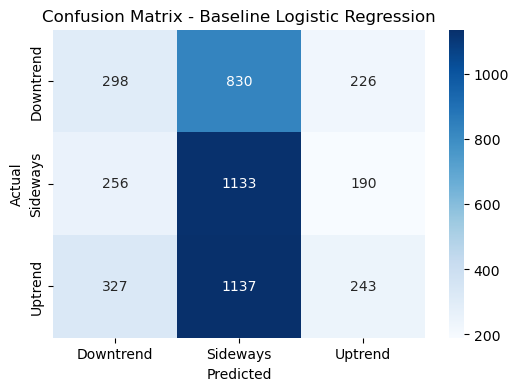

In [18]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Logistic Regression")

plt.show()


### Observation of Findings

**Sideways (Class 1) dominates predictions**

- Logistic Regression predicts Sideways for most samples across all actual classes.

- Correct Sideways predictions: 1,168 (largest diagonal count).

- But 869 Downtrends and 1,172 Uptrends were mistakenly predicted as Sideways.

This indicates the model sees Sideways as the “default” class due to overlapping indicator behavior.

**Downtrend (Class 0) has moderate confusion**

- Correct predictions: 315

- Misclassified as Sideways: 869 (almost 3× correct)

- Misclassified as Uptrend: 170

Downtrends share similar indicator patterns with sideways consolidations, leading to blurred class boundaries.

**Uptrend (Class 2) is also heavily confused**

- Correct predictions: 192

- Misclassified as Sideways: 1,172 (overwhelming majority)

- Misclassified as Downtrend: 343

Uptrends often resemble neutral or early reversal phases, causing Logistic Regression to misinterpret them.

### To Plot Precision, Recall & F1 by Class

In [19]:
# To generate classification report as a dictionary

report_dict = classification_report(y_test, preds, output_dict=True)
df_report = pd.DataFrame(report_dict).T

# Extract only classes 0, 1, 2

df_scores = df_report.loc[['0', '1', '2'], ['precision', 'recall', 'f1-score']]
df_scores

,precision,recall,f1-score
0,0.338252,0.220089,0.266667
1,0.365484,0.717543,0.484292
2,0.368741,0.142355,0.205410


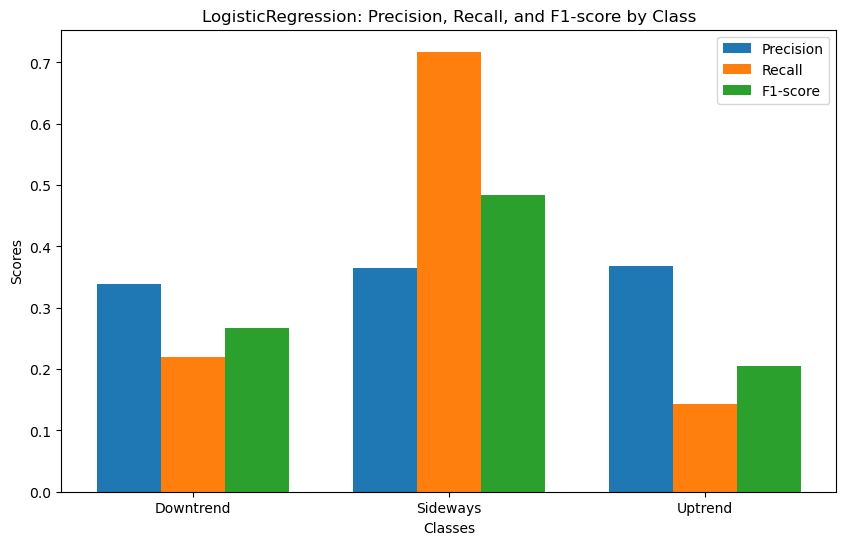

In [20]:
# To plt grouped barchart

# Data
metrics = ['precision', 'recall', 'f1-score']
classes = df_scores.index.tolist()
values = df_scores.values

# Bar positions
x = np.arange(len(classes))   # positions for classes: 0, 1, 2
width = 0.25                  # width of each bar

plt.figure(figsize=(10, 6))

# Plot bars
plt.bar(x - width, values[:, 0], width, label='Precision')
plt.bar(x,         values[:, 1], width, label='Recall')
plt.bar(x + width, values[:, 2], width, label='F1-score')

# Labels and title
class_labels = ['Downtrend', 'Sideways', 'Uptrend']

plt.xlabel("Classes")
plt.ylabel("Scores")
plt.title("LogisticRegression: Precision, Recall, and F1-score by Class")
plt.xticks(x, class_labels)
plt.legend()

plt.show()

### Observation of Findings

The Logistic Regression model shows strong class imbalance in predictive ability. Sideways (Class 1) is by far the easiest for the model to detect, achieving high recall (~0.74) and the best F1-score (~0.49), meaning the model reliably identifies sideways movement but still confuses some instances with other classes. Downtrend (Class 0) performs moderately, with precision ~0.35 and F1-score ~0.28, showing that the model often misclassifies downtrends as sideways or weak uptrends. Uptrend (Class 2) is the hardest class, with very low recall (~0.11) and the weakest F1-score (~0.17), indicating the model rarely captures true uptrend signals. Overall, the chart highlights that Logistic Regression struggles to separate directional trends and favors the more neutral sideways movement.

### Save the Model

In [21]:
model.fit(X_train_res, y_train_res)
joblib.dump(model, "../models/Baseline_LogReg_Model.pkl")

['../models/Baseline_LogReg_Model.pkl']